In [1]:
import json
import numpy as np
import pyvisa
import time
import hid # pip install hidapi
import skrf as rf
import matplotlib.pyplot as plt
import serial.tools.list_ports
from RsInstrument import RsInstrument, BinFloatFormat
from datetime import datetime
from pathlib import Path
import os
import sys
import matplotlib.colors as mcolors
from urllib.request import urlopen

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

PROGRAMMABLE_ATTENUATOR_IP_ADDRESS = '169.254.11.11'
def get_attenuation_state(ip_address):
    # The direct URL that successfully delivers the information
    url = f"http://{ip_address}/ATT?"
    
    try:
        with urlopen(url, timeout=2.0) as response:
            # Read bytes, decode to string, and remove whitespace/newlines
            attenuation_value = response.read().decode('utf-8').strip()
            return float(attenuation_value)
            
    except URLError as e:
        print(f"Connection failed: {e.reason}")
        return None
    except ValueError:
        print(f"Parsing Error: Could not convert response to number: {attenuation_value}")
        return None

In [2]:
yoko = None
for instrument in instruments:
    if 'YOKOGAWA' in instrument:
        # Initialize instrument
        yoko = rm.open_resource(instrument) 
        break

In [4]:
vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break
print(vna.query('*IDN?').strip())
vna.go_to_local()

Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30


In [12]:
arb = None
for instrument in instruments:
    if '33220A' in instrument:
        # Initialize instrument
        arb = rm.open_resource(instrument) 
        break
print(arb.query('*IDN?').strip())
arb.write("SYSTem:LOCal")

Agilent Technologies,33220A,MY44053372,2.07-2.06-22-2


14

In [6]:
print(vna.query('*IDN?'))
vna.go_to_local()

Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30


In [8]:
vna_state = {}

vna_state['idn'] = vna.query('*IDN?')
vna_state['fstart']    = float(vna.query(':SENS1:FREQ:START?'))
vna_state['fstop']     = float(vna.query(':SENS1:FREQ:STOP?'))
vna_state['numpoints'] = int(vna.query(':SENS1:SWEep:POINts?'))
vna_state['ifbw']      = float(vna.query(':SENS1:BAND?'))
vna_state['power']      = float(vna.query('SOURce1:POWer?'))

frequencies = np.linspace(vna_state['fstart'],vna_state['fstop'],vna_state['numpoints'])
fghz = frequencies/1e9
vna_state['fghz'] = fghz.tolist()
vna.go_to_local()

In [15]:
arb.write("FUNCtion DC")
noise_source_voltage = 0.0
arb.write(f"VOLTage:OFFSet {noise_source_voltage}")
arb.write("OUTPut ON")

11

0.5
0.501
0.502
0.504
0.505
0.506
0.507
0.509
0.51
0.511
0.512
0.514
0.515
0.516
0.518
0.519
0.52
0.521
0.522
0.524
0.525
0.526
0.528
0.529
0.53
0.531
0.532
0.534
0.535
0.536
0.538
0.539
0.54
0.541
0.542
0.544
0.545
0.546
0.548
0.549
0.55
0.551
0.552
0.554
0.555
0.556
0.558
0.559
0.56
0.561
0.562
0.564
0.565
0.566
0.568
0.569
0.57
0.571
0.572
0.574
0.575
0.576
0.578
0.579
0.58
0.581
0.582
0.584
0.585
0.586
0.588
0.589
0.59
0.591
0.592
0.594
0.595
0.596
0.598
0.599
0.6
0.601
0.602
0.604
0.605
0.606
0.608
0.609
0.61
0.611
0.612
0.614
0.615
0.616
0.618
0.619
0.62
0.621
0.622
0.624
0.625
0.626
0.628
0.629
0.63
0.631
0.633
0.634
0.635
0.636
0.638
0.639
0.64
0.641
0.643
0.644
0.645
0.646
0.648
0.649
0.65
0.651
0.652
0.654
0.655
0.656
0.658
0.659
0.66
0.661
0.662
0.664
0.665
0.666
0.668
0.669
0.67
0.671
0.672
0.674
0.675
0.676
0.678
0.679
0.68
0.681
0.682
0.684
0.685
0.686
0.688
0.689
0.69
0.691
0.692
0.694
0.695
0.696
0.698
0.699
0.7
0.701
0.702
0.704
0.705
0.706
0.708
0.709
0.71
0.711
0.712

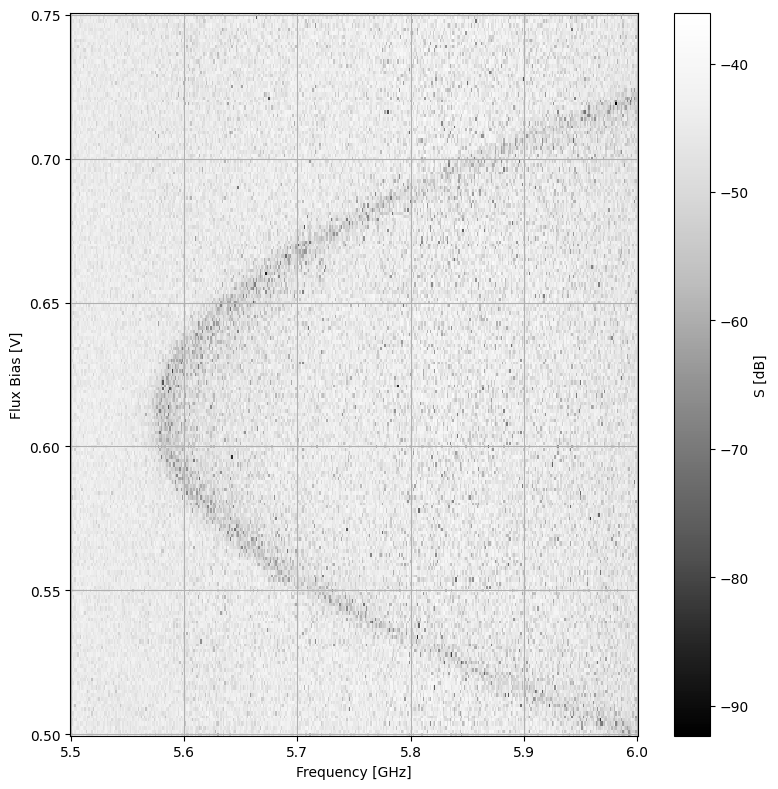

In [60]:
flux_sweep_start = 0.5
flux_sweep_stop = .75
flux_sweep_number_of_points = 201

qubit_flux_sweep = {}
qubit_flux_sweep['flux_bias'] = np.linspace(flux_sweep_start, flux_sweep_stop, flux_sweep_number_of_points)
qubit_flux_sweep['flux_bias'] = np.round(qubit_flux_sweep['flux_bias']*1000)/1000
qubit_flux_sweep['flux_bias'] = qubit_flux_sweep['flux_bias'].tolist()

try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
folder_name = datetime.now().strftime("%d-%m-%Y")
target_dir = script_dir / folder_name
target_dir.mkdir(parents=True, exist_ok=True)

now = datetime.now().astimezone()
qubit_flux_sweep['timestamp'] = int(now.timestamp())
qubit_flux_sweep['date'] = now.strftime("%d-%m-%Y")
qubit_flux_sweep['time'] = now.strftime("%H:%M:%S")
qubit_flux_sweep['timezone'] = now.tzname()
qubit_flux_sweep['temperature'] = '0.017'
qubit_flux_sweep['start_time'] = int(now.timestamp())

readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + qubit_flux_sweep['date'] + " Plots\n\n")

qubit_flux_sweep['programmable_attenuator'] = get_attenuation_state(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS)

vna_state = {}
vna_state['idn'] = vna.query('*IDN?')
vna_state['fstart']    = float(vna.query(':SENS1:FREQ:START?'))
vna_state['fstop']     = float(vna.query(':SENS1:FREQ:STOP?'))
vna_state['numpoints'] = int(vna.query(':SENS1:SWEep:POINts?'))
vna_state['ifbw']      = float(vna.query(':SENS1:BAND?'))
vna_state['power']      = float(vna.query('SOURce1:POWer?'))

frequencies = np.linspace(vna_state['fstart'],vna_state['fstop'],vna_state['numpoints'])
fghz = frequencies/1e9
qubit_flux_sweep['fghz'] = fghz.tolist()
qubit_flux_sweep['vna'] = vna_state

qubit_flux_sweep['s_db'] = []
qubit_flux_sweep['s_deg'] = []

for flux_bias in qubit_flux_sweep['flux_bias']:
    yoko.write(f":SOUR:LEV {flux_bias:.3f}")
    print(flux_bias)
    vna.bin_float_numbers_format = BinFloatFormat.Single_4bytes
    vna.write("FORM REAL,32") 
    vna.write_str(":CALC1:PAR:SEL 'Trc1'") 
    vna.write("INITiate:CONTinuous OFF")
    vna.write("INITiate:IMMediate")  
    opc_done = vna.query("*OPC?").strip()    
    if opc_done != "1":
        print(f"Error: OPC returned unexpected value '{opc_done}'; ending execution.")
        exit()
    raw_floats = vna.query_bin_or_ascii_float_list(":CALC1:DATA? SDAT")
    vna.write("INITiate:CONTinuous ON")
    vna.go_to_local()
    real_parts = np.array(raw_floats[0::2])
    imag_parts = np.array(raw_floats[1::2])
    complex_trace = real_parts + 1j * imag_parts
    s_matrix = np.zeros((len(frequencies), 1, 1), dtype=complex)
    s_matrix[:, 0, 0] = complex_trace
    trace_network = rf.Network(frequency=frequencies, s=s_matrix, name='data trace')
    qubit_flux_sweep['s_db'].append(trace_network.s_db[:,0,0])
    qubit_flux_sweep['s_deg'].append(trace_network.s_deg[:,0,0])
    time.sleep(0.05)
qubit_flux_sweep['s_db'] = np.array(qubit_flux_sweep['s_db'])
qubit_flux_sweep['s_deg'] = np.array(qubit_flux_sweep['s_deg'])
    
now = datetime.now().astimezone()
qubit_flux_sweep['finish_time'] = int(now.timestamp())
qubit_flux_sweep['sweep_time'] = qubit_flux_sweep['finish_time'] - qubit_flux_sweep['start_time']
print(str(qubit_flux_sweep['sweep_time']) + " seconds sweep time")

qubit_flux_sweep['s_db'] = qubit_flux_sweep['s_db'].tolist()
qubit_flux_sweep['s_deg'] = qubit_flux_sweep['s_deg'].tolist()

sweep_file_name = f"{qubit_flux_sweep['timestamp']}-qubit-sweep.json"
file_path = target_dir / sweep_file_name

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(qubit_flux_sweep, f, indent=4)



plt.figure(figsize=(8,8))
flux_bias = np.array(qubit_flux_sweep['flux_bias'])
fghz = np.array(qubit_flux_sweep['fghz'])
s = np.array(qubit_flux_sweep['s_db'])

mesh = plt.pcolormesh(
    fghz, 
    flux_bias, 
    s, 
    shading='auto', 
    cmap='Greys_r'
)

#plt.title(f"TWPA Pump Power = {noise_scan['twpa_pump_power']:.3f} dBm, TWPA Pump Frequency = {noise_scan['twpa_pump_frequency']/1e9:.3f} GHz")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Flux Bias [V]")

cbar = plt.colorbar(mesh)
cbar.set_label("S [dB]")

plt.tight_layout()
plt.grid()


plot_file_name = f"{qubit_flux_sweep['timestamp']}-qubit-sweep-plot.png"

with open(readme_path, "a") as file:
    file.write("![]("+ plot_file_name + ")\n")
plot_file_path = target_dir / plot_file_name
plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
plt.show()
#plt.close()


yoko.write(f":SOUR:LEV 0")
vna.go_to_local()

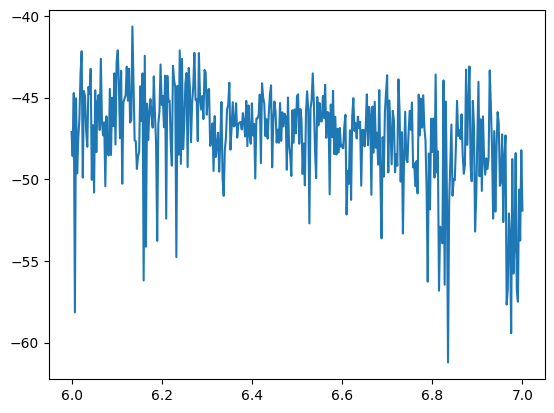

In [46]:
plt.plot(fghz,qubit_flux_sweep['s_db'][1])

In [45]:
qubit_flux_sweep['timestamp']


1788377744

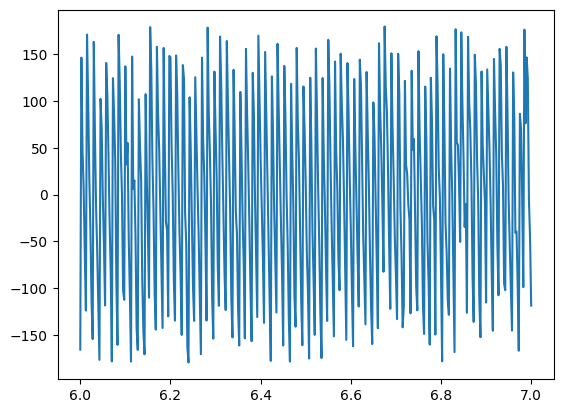

In [30]:
plt.plot(fghz,trace_deg)

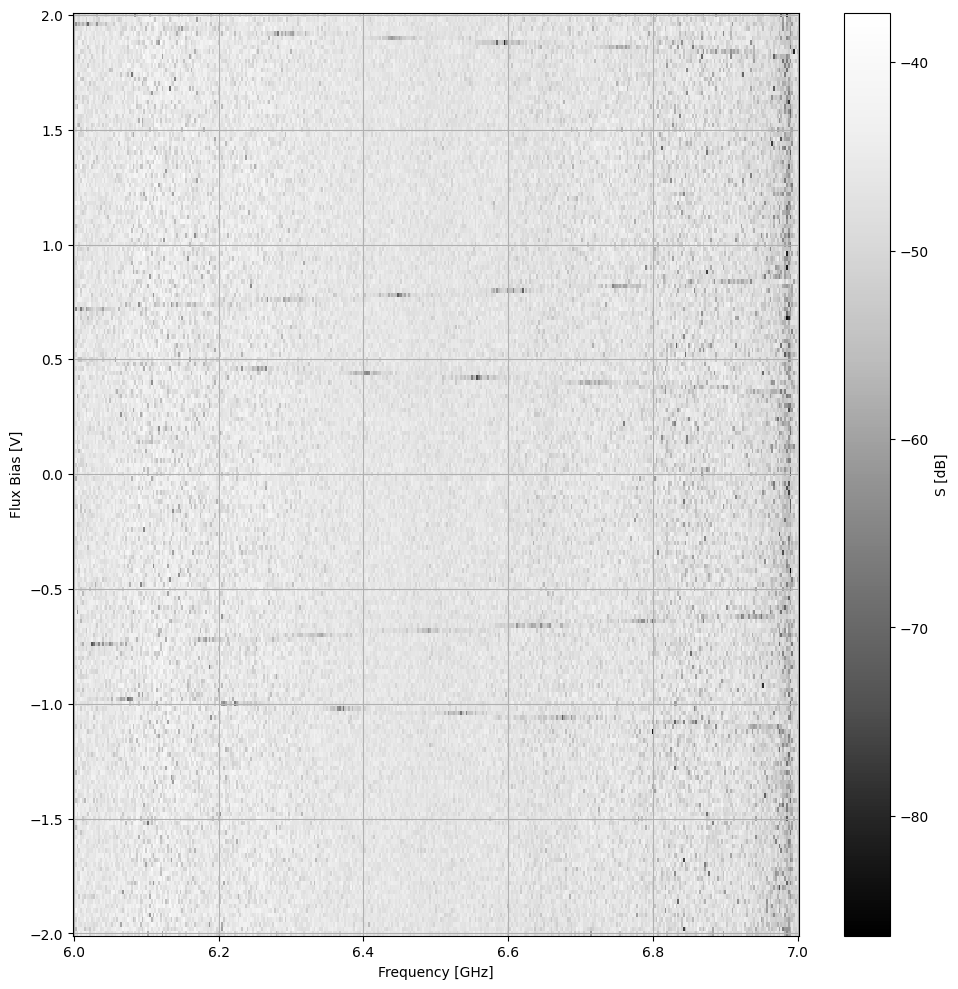

In [58]:
plt.figure(figsize=(10, 10))
flux_bias = np.array(qubit_flux_sweep['flux_bias'])
fghz = np.array(qubit_flux_sweep['fghz'])
s = np.array(qubit_flux_sweep['s_db'])

mesh = plt.pcolormesh(
    fghz, 
    flux_bias, 
    s, 
    shading='auto', 
    cmap='Greys_r'
)
#plt.title(f"TWPA Pump Power = {noise_scan['twpa_pump_power']:.3f} dBm, TWPA Pump Frequency = {noise_scan['twpa_pump_frequency']/1e9:.3f} GHz")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Flux Bias [V]")

cbar = plt.colorbar(mesh)
cbar.set_label("S [dB]")

plt.tight_layout()
plt.grid()


In [54]:
type(qubit_flux_sweep['flux_bias'])

list